!) ¿Cuales son las 3 provincias que tienen la mayor cantidad de aeropuertos?

2)¿Qué porcentaje tiene cada tipo de aeropuerto?

3)¿Cuántos aeropuertos grandes estan registrados y qué porcentaje representan del total?

4)¿En qué provincias se concentra la mayor cantidad de aeropuertos cerrados?

5)¿Cuanta elevacion tienen los 5 aeropuertos con mas elevacion?

6)¿Cuántos aeropuertos hay en cada provincia?

7)¿Cuál es la provincia que tiene mayor cantidad de aeropuertos chicos?

8)¿Cuántos aeropuertos tienen una elevación superior a 1000 metros?

9)¿Cómo se distribuyen geográficamente los aeropuertos cerrados?

10)¿Cómo se distribuyen geográficamente los aeropuertos con una elevación superior a 1000 metros?

In [1]:
import pandas as pd

In [2]:
import plotly.express as px

In [3]:
import folium

In [4]:
def generar_mapa():
    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )
    
    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'
    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )
    return m

    mapa = generar_mapa()

In [8]:
aeropuerto = pd.read_csv("ar-airports.csv")

1)Las 3 provincias con mas aeropuertos son Buenos Aires, Cordoba y Santa Fe

In [9]:
print(aeropuerto["region_name"].value_counts())

region_name
Buenos Aires Province             268
Córdoba Province                  100
Santa Fe Province                  97
Santa Cruz Province                75
Entre Ríos Province                44
Chubut Province                    41
Corrientes Province                35
Río Negro Province                 32
Neuquén Province                   31
La Pampa Province                  29
Salta Province                     26
Tierra del Fuego Province          24
Mendoza Province                   23
Santiago del Estero Province       22
Chaco Province                     20
Misiones Province                  16
Buenos Aires (Autonomous City)     14
Formosa Province                   12
San Luis Province                  12
Catamarca Province                  9
Tucumán Province                    8
Jujuy Province                      7
La Rioja Province                   6
San Juan Province                   5
Name: count, dtype: int64


2)72.6 Small airport, 15.5 Heliport, 7.22 Medium airport, 4.39 Closed, 0.209 Large y 0.105 Balloonport

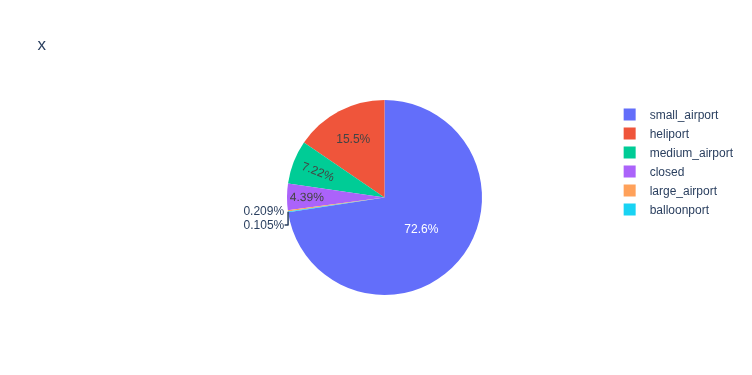

In [10]:
grafico = aeropuerto["type"].value_counts()
px.pie(data_frame = grafico, values = grafico.values, names = grafico.index, title = "x").show()

3)Hay 2 aeropuertos grandes registrados

In [12]:
filtro = aeropuerto[aeropuerto["type"] == "large_airport"]
print(filtro.shape)

(2, 24)


4)La provincia con mas aeropuertos cerrados es Buenos Aires

In [13]:
filtro = aeropuerto[aeropuerto["type"] == "closed"]
print(filtro["region_name"].value_counts())

region_name
Buenos Aires Province           12
Santiago del Estero Province     6
Santa Fe Province                4
Entre Ríos Province              3
Río Negro Province               2
Santa Cruz Province              2
Córdoba Province                 2
La Rioja Province                2
Corrientes Province              2
Misiones Province                2
Chaco Province                   2
San Luis Province                1
La Pampa Province                1
Catamarca Province               1
Name: count, dtype: int64


5)Las elevaciones son 13000, 11810, 11414, 10477 y 8232

In [14]:
print(aeropuerto.sort_values(by="elevation_ft", ascending=False))

         id    ident           type  \
680   41558     SASL  small_airport   
930   42900  AR-0478       heliport   
492    5798     SAOL  small_airport   
328   41551     SAMC  small_airport   
236      13     SA01  small_airport   
..      ...      ...            ...   
760  313022  AR-0501  small_airport   
778   46643  AR-0342  small_airport   
883   38721  AR-0046       heliport   
903   42897  AR-0475       heliport   
938  354551  AR-0732       heliport   

                                               name  latitude_deg  \
680                       Salar De Cauchari Airport    -24.019199   
930                          Pachón Minera Heliport    -31.759700   
492                               La Quiaca Airport    -22.165264   
328                         Cristo Redentor Airport    -32.807301   
236                                   Cachi Airport    -25.105000   
..                                              ...           ...   
760                             Caleta Valdés Fi

6)Buenos Aires 268
Córdoba 100
Santa Fe 97
Santa Cruz 75
Entre Ríos 44
Chubut 41
Corrientes 35
Río Negro 32
Neuquén 31
La Pampa 29
Salta 26
Tierra del Fuego 24
Mendoza 23
Santiago del Estero 22
Chaco 20
Misiones 16
CABA 14
Formosa 12
San Luis 12
Catamarca 9
Tucumán 8
Jujuy 7
La Rioja 6
San Juan 5

In [15]:
print(aeropuerto["region_name"].value_counts())

region_name
Buenos Aires Province             268
Córdoba Province                  100
Santa Fe Province                  97
Santa Cruz Province                75
Entre Ríos Province                44
Chubut Province                    41
Corrientes Province                35
Río Negro Province                 32
Neuquén Province                   31
La Pampa Province                  29
Salta Province                     26
Tierra del Fuego Province          24
Mendoza Province                   23
Santiago del Estero Province       22
Chaco Province                     20
Misiones Province                  16
Buenos Aires (Autonomous City)     14
Formosa Province                   12
San Luis Province                  12
Catamarca Province                  9
Tucumán Province                    8
Jujuy Province                      7
La Rioja Province                   6
San Juan Province                   5
Name: count, dtype: int64


7)La provincia con mas aeropuertos chicos es Buenos Aires

In [16]:
filtro = aeropuerto[aeropuerto["type"] == "small_airport"]
print(filtro["region_name"].value_counts())

region_name
Buenos Aires Province           188
Santa Fe Province                82
Córdoba Province                 76
Santa Cruz Province              57
Chubut Province                  37
Entre Ríos Province              35
Corrientes Province              27
La Pampa Province                24
Río Negro Province               22
Salta Province                   19
Mendoza Province                 18
Neuquén Province                 18
Chaco Province                   17
Santiago del Estero Province     12
Tierra del Fuego Province        11
Formosa Province                 11
Misiones Province                 9
San Luis Province                 8
Catamarca Province                6
Jujuy Province                    6
Tucumán Province                  6
San Juan Province                 3
La Rioja Province                 2
Name: count, dtype: int64


8)Hay 210 aeropuertos con mayor elevacion a 1000 registrados

In [21]:
filtro = aeropuerto[aeropuerto["elevation_ft"] > 1000]
print(filtro.shape)

(210, 24)


9)Asi estan distribuidos

In [20]:
def generar_mapa():
    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )
    
    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'
    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )
    return m

mapa = generar_mapa()
    
filtro = aeropuerto[aeropuerto["type"] == "closed"]
def agregar_marca_lago(row):
    colores = {"closed": "blue",}
    color = colores.get(row['type'], 'gray')
    folium.CircleMarker( 
        location=[row['latitude_deg'], row['longitude_deg']],
        radius=6,
        color=color,
        fill=True,
        popup=row['name']
        ).add_to(mapa)

filtro.apply(agregar_marca_lago, axis=1)
mapa

10)Asi estan distribuidos

In [23]:
def generar_mapa():
    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )
    
    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'
    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )
    return m

mapa = generar_mapa()
filtro = aeropuerto[aeropuerto["elevation_ft"] > 1000]
def agregar_marca_lago(row):
    colores = {"closed": "blue",
              "large_airport": "red",
              "medium_airport": "yellow",
              "small_airport": "green",
              "heliport": "pink",
              "balloonport": "purple",}
    color = colores.get(row['type'], 'gray')
    folium.CircleMarker( 
        location=[row['latitude_deg'], row['longitude_deg']],
        radius=6,
        color=color,
        fill=True,
        popup=row['name']
        ).add_to(mapa)

filtro.apply(agregar_marca_lago, axis=1)
mapa